In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/kaggle/input/datasets/chiagoziemichael/churn-bigml/churn-bigml-80.csv")

df['International plan'] = df['International plan'].map({'Yes': 1, 'No': 0})
df['Voice mail plan'] = df['Voice mail plan'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].astype(int) 

X = df.drop(columns=['State', 'Area code', 'Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [3]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
}).sort_values(by='Odds Ratio', ascending=False)

print("--- Coefficients and Odds Ratios ---")
print(coef_df.to_string(index=False))

--- Coefficients and Odds Ratios ---
               Feature  Coefficient  Odds Ratio
Customer service calls     0.739687    2.095279
    International plan     0.687970    1.989673
     Total day minutes     0.369427    1.446905
      Total day charge     0.368903    1.446147
 Number vmail messages     0.156164    1.169018
     Total intl charge     0.152891    1.165198
    Total intl minutes     0.147872    1.159365
     Total eve minutes     0.147378    1.158792
      Total eve charge     0.145742    1.156897
    Total night charge     0.098702    1.103737
   Total night minutes     0.097621    1.102545
       Total day calls     0.052835    1.054256
     Total night calls     0.044026    1.045009
        Account length     0.041168    1.042028
       Total eve calls    -0.003540    0.996466
      Total intl calls    -0.299353    0.741298
       Voice mail plan    -0.590461    0.554072


--- Evaluation Metrics ---
Accuracy:  0.8408
Precision: 0.4054
Recall:    0.1923


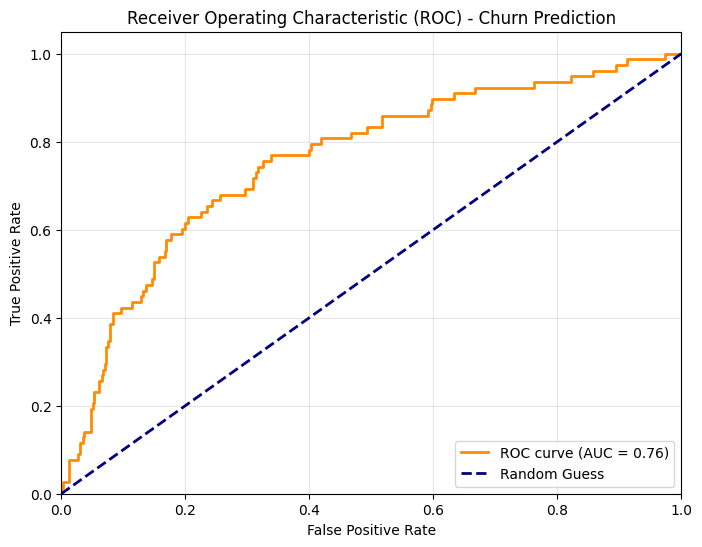

In [4]:

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] 

print("--- Evaluation Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Churn Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()